In [1]:
import sys
sys.path.append('../..')

In [2]:
from src.io_tools import *
from src.l1_tools import conc_calculation , calculate_AMB_clear , remove_nans_interpolation
import pandas as pd

In [3]:
data = read_nc_file_("../../data/Case_2/raw/ipral_1a_Lz1Lb87R15mF30sPbckIqsmart_v01_20250611_000000_1440.nc")
print(data.keys())


dict_keys(['time', 'range', 'time_bnds', 'lat', 'lon', 'altitude', 'wavelength', 'telescope', 'voltage', 'polarization', 'detection_mode', 'filter_wheel_position', 'bin_shift', 'adc_bits', 'discriminator_level', 'adc_range', 'l0_wavelength', 'l0_beam_diam', 'l0_beam_div', 'l0_prf', 'l1_wavelength', 'l1_beam_diam', 'l1_beam_div', 'l1_prf', 'l2_wavelength', 'l2_beam_diam', 'l2_beam_div', 'l2_prf', 't0_ad', 't0_od', 't0_fl', 't0_fov', 't1_ad', 't1_od', 't1_fl', 't1_fov', 'rcs_00', 'bckgrd_rcs_00', 'rcs_01', 'bckgrd_rcs_01', 'rcs_02', 'bckgrd_rcs_02', 'rcs_03', 'bckgrd_rcs_03', 'rcs_04', 'bckgrd_rcs_04', 'rcs_05', 'bckgrd_rcs_05', 'rcs_06', 'bckgrd_rcs_06', 'rcs_07', 'bckgrd_rcs_07', 'rcs_08', 'bckgrd_rcs_08', 'rcs_09', 'bckgrd_rcs_09', 'rcs_10', 'bckgrd_rcs_10', 'rcs_11', 'bckgrd_rcs_11', 'rcs_12', 'bckgrd_rcs_12', 'rcs_13', 'bckgrd_rcs_13', 'rcs_14', 'bckgrd_rcs_14', 'rcs_15', 'bckgrd_rcs_15', 'rcs_16', 'bckgrd_rcs_16', 'rcs_17', 'bckgrd_rcs_17', 'time_resol', 'range_resol', 'tilt_angle'

In [4]:
time= np.array(days_since_1970_to_datetime(data["time"]))
alt = np.array(data["range"])

print(np.shape(time))
print(np.shape(alt))

(2743,)
(4000,)


In [5]:
rcs_02 = get_corrected_signal( data , alt ,rcs_="rcs_02")
rcs_03 = get_corrected_signal( data , alt ,rcs_="rcs_03")
rcs_04 = get_corrected_signal( data , alt ,rcs_="rcs_04")
rcs_05 = get_corrected_signal( data , alt ,rcs_="rcs_05")

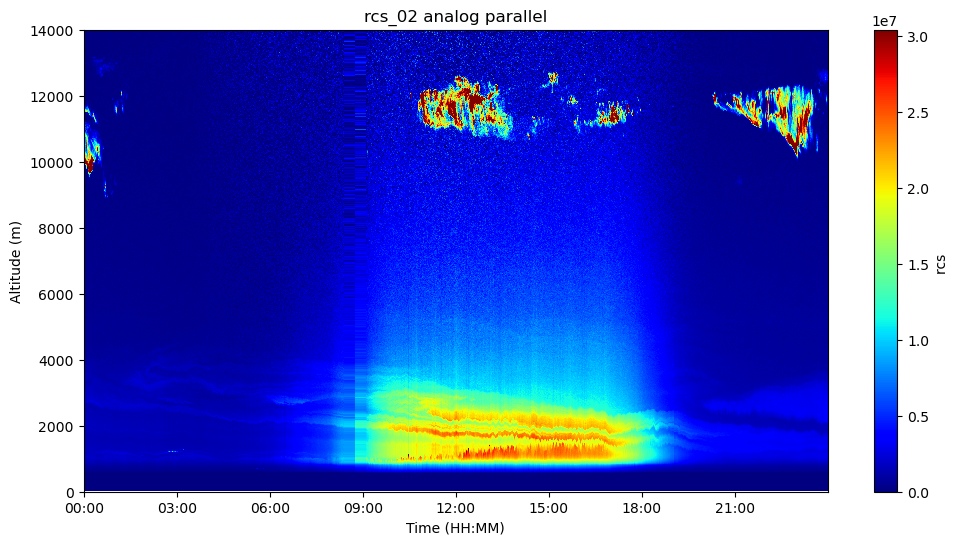

In [6]:
plt.figure(figsize=(12, 6)) 
vmax= np.percentile(rcs_02 , 97)
plot_rcs(rcs_02 , time , alt ,"rcs_02 analog parallel" , vmax=vmax , vmin=0 , y_limit=(0,14000) , save=False) 

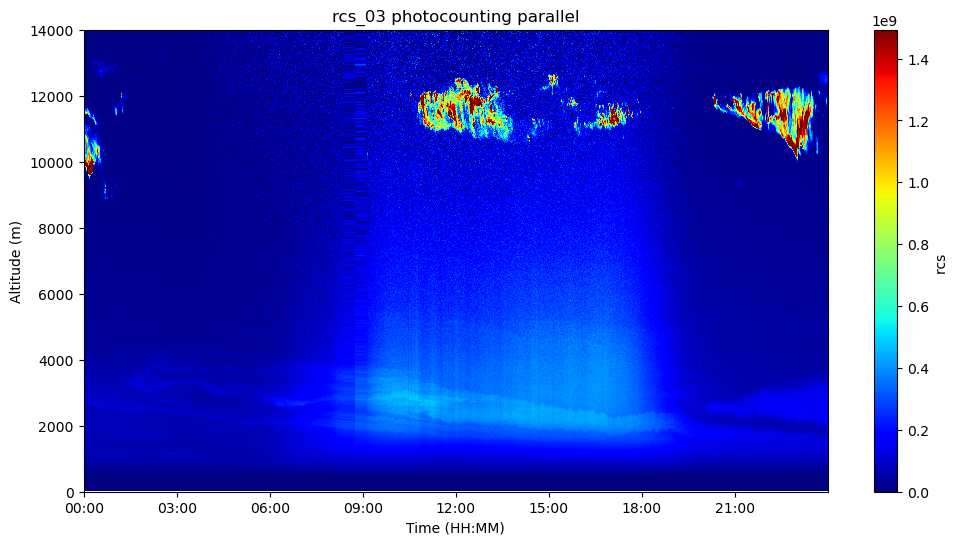

In [7]:
plt.figure(figsize=(12, 6)) 
vmax= np.percentile(rcs_03 , 97)
plot_rcs(rcs_03 , time , alt , "rcs_03 photocounting parallel" , vmax=vmax , vmin=0 ,  y_limit=(0,14000), save=False)  


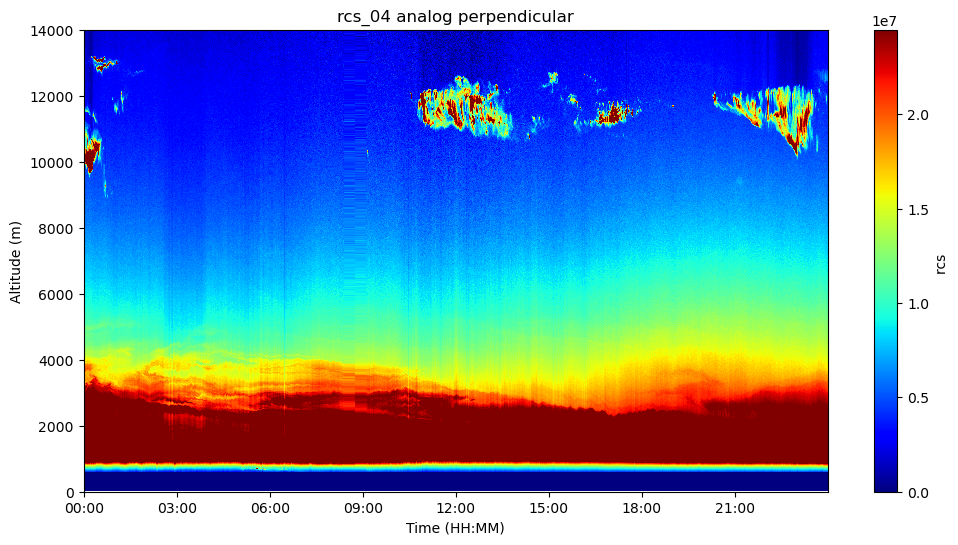

In [8]:
plt.figure(figsize=(12, 6)) 
vmax= np.percentile(rcs_04 , 97)
plot_rcs(rcs_04 , time , alt , "rcs_04 analog perpendicular" , vmax=vmax , vmin=0 , y_limit=(0,14000), save=False) 

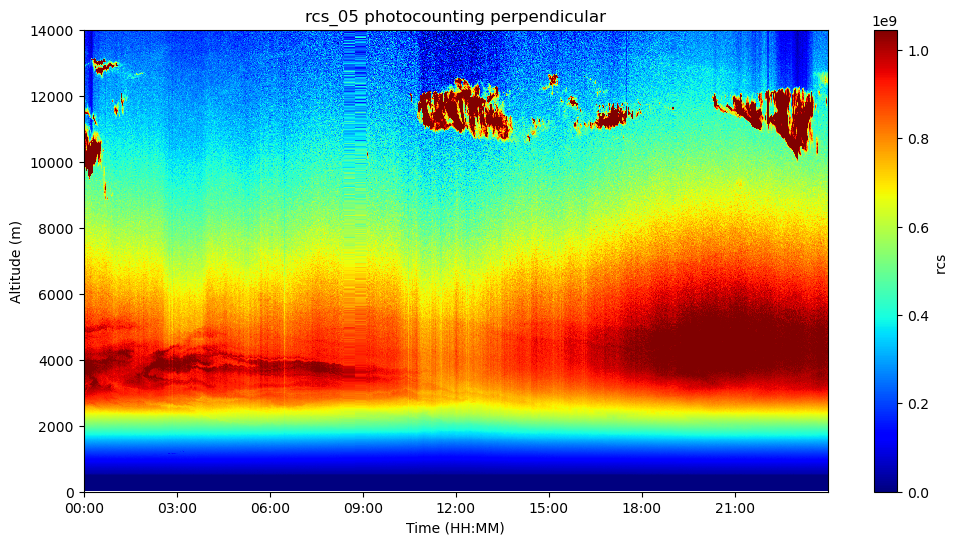

In [9]:
plt.figure(figsize=(12, 6)) 
vmax= np.percentile(rcs_05 , 97)
plot_rcs(rcs_05 , time , alt , "rcs_05 photocounting perpendicular" , vmax=vmax , vmin=0 , y_limit=(0,14000), save=False) 

In [10]:
start_time_clear='2025-06-11T01:30:00'
end_time_clear='2025-06-11T01:50:00'

index_clear =np.array( get_indx_from_range_time_sirta(start_time_clear , end_time_clear , time))


In [11]:
RCS_02 = np.nanmean(rcs_02[index_clear,:], axis=0)
RCS_03 = np.nanmean(rcs_03[index_clear,:], axis=0)
RCS_04 = np.nanmean(rcs_04[index_clear,:], axis=0)
RCS_05 = np.nanmean(rcs_05[index_clear,:], axis=0)

In [12]:
df = pd.DataFrame({
    'Altitude_m': alt,
    'RCS_02': RCS_02,
    'RCS_03': RCS_03,
    'RCS_04': RCS_04,
    'RCS_05': RCS_05
})

In [13]:
df.to_csv("../../data/Case_2/processed/clear_sky_mean_profiles.csv", index=False)
print("Saved as CSV!")

Saved as CSV!


In [14]:
start_time_cloud='2025-06-11T21:00:00'
end_time_cloud='2025-06-11T21:30:00'

index_cloudy =np.array( get_indx_from_range_time_sirta(start_time_cloud , end_time_cloud , time))


In [15]:
RCS_02_ = np.nanmean(rcs_02[index_cloudy,:], axis=0)
RCS_03_ = np.nanmean(rcs_03[index_cloudy,:], axis=0)
RCS_04_ = np.nanmean(rcs_04[index_cloudy,:], axis=0)
RCS_05_ = np.nanmean(rcs_05[index_cloudy,:], axis=0)


In [16]:
df_ = pd.DataFrame({
    'Altitude_m': alt,
    'RCS_02': RCS_02_,
    'RCS_03': RCS_03_,
    'RCS_04': RCS_04_,
    'RCS_05': RCS_05_
})

In [17]:
df_.to_csv("../../data/Case_2/processed/cloudy_sky_mean_profiles.csv", index=False)
print("Saved as CSV!")


Saved as CSV!


In [18]:
rs_file="../../data/Case_2/raw/rs_2a_GRUAN_TRP_M10_20250611_231549_v2.0.1.nc"
conc , alt_rs , temp = conc_calculation(rs_file)



In [19]:
depolarization_ratio_mol = 0.004
AMB_clear  , beta_ray , alpha_ray =  calculate_AMB_clear( conc ,alt_rs, alt  )
AMB_clear_parallel = AMB_clear / (1 + depolarization_ratio_mol)
AMB_clear_perpendicular = (AMB_clear * depolarization_ratio_mol )/ (1 + depolarization_ratio_mol)


beta_ray_parallel = beta_ray / (1 + depolarization_ratio_mol)
beta_ray_perpendicular = (beta_ray * depolarization_ratio_mol )/ (1 + depolarization_ratio_mol)



In [20]:
AMB_clear =remove_nans_interpolation(AMB_clear, alt)
AMB_clear_parallel =remove_nans_interpolation(AMB_clear_parallel, alt)
AMB_clear_perpendicular =remove_nans_interpolation(AMB_clear_perpendicular, alt)

beta_ray = remove_nans_interpolation(beta_ray, alt)
beta_ray_parallel = remove_nans_interpolation(beta_ray_parallel, alt)
beta_ray_perpendicular = remove_nans_interpolation(beta_ray_perpendicular, alt)   

In [21]:

dades_moleculars = {
    "Altitude_m": alt,
    "AMB_clear": AMB_clear,
    "AMB_clear_parallel": AMB_clear_parallel,
    "AMB_clear_perpendicular": AMB_clear_perpendicular,
    "beta_ray": beta_ray,
    "beta_ray_parallel": beta_ray_parallel,
    "beta_ray_perpendicular": beta_ray_perpendicular
}

df_mol = pd.DataFrame(dades_moleculars)


csv_mol_file = "../../data/Case_2/processed/molecular_profiles_reference.csv"
df_mol.to_csv(csv_mol_file, index=False)

print(f"CSV mol saved successfully! in : {csv_mol_file}")

CSV mol saved successfully! in : ../../data/Case_2/processed/molecular_profiles_reference.csv
